# Atividade: Classificação de Grãos

## Dataset
Para esta tarefa, utilizaremos uma versão adaptada do Dry Bean Dataset, disponível no arquivo `beans_train.csv`. O conjunto é composto por amostras de diferentes tipos de feijões secos, descritas por atributos morfológicos extraídos a partir de imagens, como área, perímetro, compacidade, excentricidade e fatores de forma. Essas características capturam propriedades geométricas relevantes dos grãos, permitindo distinguir classes com base em padrões estruturais no espaço de atributos.

As amostras estão organizadas em sete classes distintas de feijões: Seker, Barbunya, Bombay, Cali, Dermason, Horoz e Sira.

## O que será avaliado
Serão considerados os seguintes aspectos:

* **Implementação:** Coerência entre o problema proposto e o método de classificação adotado, bem como a correta aplicação do algoritmo.
* **Estabilidade:** Controle do comportamento do processo de treinamento, assegurando convergência consistente e reduzindo variações indesejadas ao longo da otimização.
* **Regularização:** Capacidade de mitigar o sobreajuste por meio de estratégias adequadas ao modelo e aos dados.
* **Análise de Desempenho:** Interpretação dos resultados com base em métricas apropriadas de avaliação.

## Entrega
A atividade deve ser entregue obrigatoriamente em formato de **Jupyter Notebook (.ipynb)**. O arquivo deve estar devidamente organizado e comentado, justificando as decisões tomadas para garantir a estabilidade e a capacidade de generalização do modelo.


# Desenvolvimento da Atividade

## Investigação preliminar dos dados


Nessa investigação buscamos compreender de forma básica as características dos dados do dataset beans_train.csv.
Para isso vamos ler o dataset num dataframe pandas e levantar algumas estatisticas. Em função disso vamos determinar os passo necessários de pre-processamento que serão utilizados.

In [1]:
import torch
import pandas as pd

df = pd.read_csv('beans_train.csv')

# Seleciona o dispositivo com prioridade: CUDA > MPS > CPU
device = torch.device(
    'cuda' if torch.cuda.is_available() # GPU
    else 'mps' if torch.backends.mps.is_available() # MPS (Mac Silicon)
    else 'cpu' # CPU
)
print(f"Usando o dispositivo: {device}")

Usando o dispositivo: mps


### Visualizando as primeiras 10 linhas

In [2]:
df.head(10)

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,38465.705594,737.090445,273.111968,179.201525,1.523333,0.753998,38999.014066,220.991553,0.813252,0.988670,0.888416,0.809359,0.007117,0.001879,0.655710,0.996874,SIRA
1,70247.179155,1019.740591,376.308440,238.192942,1.582115,0.773556,71562.831696,299.139162,0.707757,0.985750,0.850248,0.794947,0.005351,0.001324,0.632118,0.998320,BARBUNYA
2,74212.949558,1049.756998,414.858346,229.655950,1.810139,0.834413,75004.806409,306.719019,0.776048,0.987679,0.844313,0.739884,0.005597,0.001039,0.548725,0.991096,CALI
3,31233.029736,671.584675,257.751304,154.448259,1.670969,0.800540,31682.423625,198.813755,0.718182,0.988299,0.870828,0.773574,0.008257,0.001822,0.598230,0.996528,DERMASON
4,48189.750788,826.752018,313.328739,196.497443,1.604009,0.781591,48840.530648,247.963648,0.796755,0.988498,0.887039,0.788613,0.006525,0.001556,0.622442,0.995508,SIRA
5,57356.907479,958.191465,400.523353,182.796156,2.186816,0.889473,57860.551234,269.985000,0.569907,0.988100,0.782668,0.673195,0.007018,0.000892,0.453699,0.992911,HOROZ
6,32171.814046,659.848322,239.925576,171.207725,1.408751,0.704095,32773.991337,203.133528,0.732065,0.986681,0.926887,0.842839,0.007454,0.002320,0.708291,0.997717,DERMASON
7,54115.074552,855.886477,286.734712,242.350112,1.180368,0.531732,54686.273502,262.825642,0.788499,0.990122,0.933415,0.919372,0.005270,0.002320,0.845115,0.997845,SEKER
8,77259.272204,1096.973650,385.738417,256.126058,1.508870,0.748752,78685.329186,314.300183,0.773244,0.983759,0.809262,0.812457,0.004993,0.001348,0.658929,0.995432,BARBUNYA
9,36349.710092,689.671173,242.197615,190.452403,1.270238,0.616005,36493.668120,214.491109,0.776832,0.990745,0.952517,0.886411,0.006695,0.002553,0.786668,0.998273,SEKER


### Calculando a distribuição das featureas: médias, desvio padrão, percentis, máximos e mínimos

In [3]:
df.describe()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,10888.000000,10888.000000,10888.000000,10888.000000,10888.000000,10888.000000,10888.000000,10888.000000,10888.000000,10888.000000,10888.000000,10888.000000,10888.000000,10888.000000,10888.000000,10888.000000
mean,52984.826554,854.735445,319.900759,202.160613,1.582773,0.750914,53707.155435,252.908484,0.749728,0.987122,0.873351,0.799940,0.006567,0.001718,0.643693,0.995069
std,29295.457791,214.444640,85.691172,44.964220,0.245892,0.091630,29749.674675,59.182734,0.048963,0.004668,0.059242,0.061495,0.001130,0.000596,0.098626,0.004390
min,20345.408013,524.528134,183.312292,122.327171,1.026275,0.218787,20684.208989,161.412105,0.555519,0.943587,0.571799,0.645318,0.002777,0.000568,0.416878,0.950032
25%,36287.942022,702.783268,253.116922,175.613608,1.433148,0.716372,36637.411296,214.876017,0.718193,0.985636,0.832720,0.762659,0.005905,0.001155,0.581743,0.993741
50%,44534.203579,794.101721,296.618790,192.380899,1.549896,0.764116,45050.873268,238.145830,0.759660,0.988270,0.883286,0.801594,0.006648,0.001700,0.642496,0.996399
75%,61301.065303,976.352085,376.380761,216.986950,1.706149,0.810119,62219.957215,279.298556,0.786905,0.989989,0.916905,0.834040,0.007280,0.002173,0.695535,0.997896
max,254495.210567,1987.238396,738.618173,460.043477,2.389710,0.908263,263278.394353,569.109998,0.866303,0.994666,0.990888,0.987507,0.010451,0.003664,0.975513,0.999727


### Encontrando as features com maior e menor média e desvio padrão

In [4]:
def explore_dataset(s):
  '''
  Retorna o índice e o valor mínimo e máximo de um série
  '''
  return s.idxmin(), s.min(), s.idxmax(), s.max()

numeric_df = df.drop(columns=['Class'])
# médias de cada atributo numérico
means = numeric_df.mean()

# mínimo e máximo entre as médias
min_means_attr, min_means_value, max_means_attr, max_means_value = explore_dataset(means)

# desvios padrão de cada atributo numérico
deviations = numeric_df.std()
min_deviations_attr, min_deviations_value, max_deviations_attr, max_deviations_value = explore_dataset(deviations)

print(f"Menor média........: {min_means_attr} = {min_means_value:.4f}")
print(f"Menor desvio padrão: {min_deviations_attr} = {min_deviations_value:.6f}")
print( "Atributo com a menor média é igual ao atributo com o menor desvio padrão" if min_means_attr == min_deviations_attr 
      else "Atributo com a menor média e atributo com o menor desvio padrão são diferentes")
print()
print(f"Maior média........: {max_means_attr} = {max_means_value:.2f}")
print(f"Maior desvio padrão: {max_deviations_attr} = {max_deviations_value:.2f}")
print( "Atributo com a maior média é igual ao atributo com o maior desvio padrão" if max_means_attr == max_deviations_attr 
      else "Atributo com a maior média e atributo com o maior desvio padrão são diferentes")

Menor média........: ShapeFactor2 = 0.0017
Menor desvio padrão: ShapeFactor2 = 0.000596
Atributo com a menor média é igual ao atributo com o menor desvio padrão

Maior média........: ConvexArea = 53707.16
Maior desvio padrão: ConvexArea = 29749.67
Atributo com a maior média é igual ao atributo com o maior desvio padrão


In [5]:
df.info()
print(f"O dataset possui {df.shape[0]} amostras e {df.shape[1]} atributos: shape {df.shape}")

<class 'pandas.DataFrame'>
RangeIndex: 10888 entries, 0 to 10887
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             10888 non-null  float64
 1   Perimeter        10888 non-null  float64
 2   MajorAxisLength  10888 non-null  float64
 3   MinorAxisLength  10888 non-null  float64
 4   AspectRation     10888 non-null  float64
 5   Eccentricity     10888 non-null  float64
 6   ConvexArea       10888 non-null  float64
 7   EquivDiameter    10888 non-null  float64
 8   Extent           10888 non-null  float64
 9   Solidity         10888 non-null  float64
 10  roundness        10888 non-null  float64
 11  Compactness      10888 non-null  float64
 12  ShapeFactor1     10888 non-null  float64
 13  ShapeFactor2     10888 non-null  float64
 14  ShapeFactor3     10888 non-null  float64
 15  ShapeFactor4     10888 non-null  float64
 16  Class            10888 non-null  str    
dtypes: float64(16), str(1)


### Observações importantes

A partir da exploração inicial do dataset, destacam-se os seguintes pontos:

1. O conjunto de dados possui 10888 amostras, com 16 atributos (features) e 1 variável de classe, totalizando 17 colunas (shape: 10888 × 17).
2. Não foram identificados valores nulos em nenhuma das colunas, não sendo necessária, portanto, uma etapa de limpeza preliminar.
3. Todos os 16 atributos são numéricos, do tipo *float64*, eliminando a necessidade de pré-processamento para codificação de variáveis não numéricas.
4. Observa-se uma diferença significativa de escala entre os atributos; a feature com menor média e desvio padrão (ShapeFactor2) apresenta $\mu=0.0017$ e $\sigma=0.000596$, enquanto a feature com maior média e desvio padrão (ConvexArea) apresenta $\mu=53707.16$ e $\sigma=29749.67$.

Diante desse cenário, evidencia-se a necessidade de normalização dos dados de entrada, a fim de mitigar o viés decorrente das diferenças de escala entre os atributos.

*IMPORTANTE:* Por questões metodológicas, os dados devem ser particionados em conjuntos de treino, validação e teste. Os parâmetros de normalização (média $\mu$ e desvio padrão $\sigma$) serão estimados exclusivamente a partir do conjunto de treino e, em seguida, aplicados de forma consistente aos conjuntos de validação e teste. Esse procedimento busca evitar o vazamento de informação (*data leakage*) e garantir a comparabilidade entre os conjuntos durante o processo de treinamento e avaliação dos modelos.

## Metodologia

Em função da investigação preliminar realizada, decidimos adotar a seguinte metodologia experimental para este trabalho:

1. **Pré-processamento:** os dados são particionados em conjunto de desenvolvimento (90%) e conjunto de teste (10%), preservando-se a distribuição das classes por meio de amostragem estratificada. O conjunto de desenvolvimento será utilizado nas etapas de seleção de hiperparâmetros e treinamento dos modelos, enquanto o conjunto de teste permanecerá isolado para avaliação final.

2. **Normalização dos dados:** os atributos são padronizados por meio de normalização do tipo Z-score. Em todas as etapas do experimento, os parâmetros de normalização (média e desvio padrão) são estimados exclusivamente sobre os dados de treino de cada partição e posteriormente aplicados aos respectivos subconjuntos de validação. Esse procedimento é adotado tanto na etapa de holdout quanto na validação cruzada, evitando vazamento de informação (*data leakage*) entre os conjuntos.

3. **Busca de hiperparâmetros:** define-se um espaço de busca contendo diferentes configurações de hiperparâmetros das MLPs, incluindo número de camadas, quantidade de neurônios, funções de ativação, algoritmos de otimização, taxas de aprendizado, entre outras. A exploração desse espaço é realizada por meio de uma estratégia holdout aplicada ao conjunto de desenvolvimento, utilizando uma fração de 10% para validação. Ao final dessa etapa, são selecionadas as N configurações mais promissoras com base no desempenho obtido, N a ser definido posteriormente com base nos experimentos, mas garantinso $N \ge 3$

4. **Treinamento dos modelos:** as N configurações selecionadas são avaliadas por meio de validação cruzada estratificada com k=10 partições (StratifiedKFold), utilizando todo o conjunto de desenvolvimento. Para cada partição, o modelo é treinado e avaliado, permitindo obter estimativas mais robustas e menos sensíveis à variabilidade dos dados.

5. **Comparação estatística:** os resultados obtidos ao longo das partições são utilizados para comparar os modelos, possibilitando a aplicação de testes estatísticos e a seleção da configuração final.

6. **Avaliação final:** o modelo selecionado é retreinado utilizando todo o conjunto de desenvolvimento e avaliado no conjunto de teste, previamente mantido isolado, a fim de obter uma estimativa imparcial de desempenho.

De forma geral, adota-se o F1-score macro como métrica principal de avaliação, por considerar de forma equilibrada o desempenho em todas as classes. Adicionalmente, o F1-score ponderado e a acurácia são utilizados como métricas complementares para análise dos resultados.

## Pré-processamento

### Particionando os dados

Vamos particionar os dados nos conjuntos de treino+validação (90%) e teste (10%), mantendo a estratificação das espécies para preservar a representatividade dos dados.

In [6]:
from sklearn.model_selection import train_test_split

SEED = 42

# separa features e classe
X = df.drop(columns=['Class'])
y = df['Class']

# 1) treino+validação (90%) e teste (10%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.1,
    stratify=y,
    random_state=SEED
)

print(f"len(X_train)={len(X_train)}, len(X_test)={len(X_test)}")

len(X_train)=9799, len(X_test)=1089


#### Conferindo a estratificação das espécies

A estratégia de amostragem estratificada preservou a distribuição das classes entre os conjuntos de treino+validação e teste, apresentando variações desprezíveis decorrentes apenas do arredondamento no particionamento das amostras, como podemos observar a seguir:

In [7]:
dist = pd.DataFrame({
    "Original": y.value_counts(),
    "Original (%)": y.value_counts(normalize=True),
    "Treino+Validação": y_train.value_counts(),
    "Treino+Validação (%)": y_train.value_counts(normalize=True),
    "Teste": y_test.value_counts(),
    "Teste (%)": y_test.value_counts(normalize=True),
})

dist

,Original,Original (%),Treino+Validação,Treino+Validação (%),Teste,Teste (%)
Class,,,,,,
DERMASON,2849,0.261664,2564,0.261659,285,0.261708
SIRA,2119,0.194618,1907,0.194612,212,0.194674
SEKER,1613,0.148145,1452,0.148178,161,0.147842
HOROZ,1522,0.139787,1370,0.139810,152,0.139578
CALI,1306,0.119949,1175,0.119910,131,0.120294
BARBUNYA,1063,0.097630,957,0.097663,106,0.097337
BOMBAY,416,0.038207,374,0.038167,42,0.038567


Com isso, temos os dados organizados da seguinte forma nos dataframes:

- Treinamento: ```X_train``` e ```y_train```;
- Teste: ```X_test``` e ```y_test```.

## Busca de Hiperpârametros

Na busca de hiperparâmetros vamos utilizar a classe `MLPConfig` para definir uma estrutura de configuração padronizada. Vamos utiliza-la para especificar arquiteturas e hiperparâmetros das redes neurais. Seu principal objetivo é organizar, de forma clara e reprodutível, os parâmetros necessários para a construção e treinamento dos modelos avaliados nos experimentos.

A utilização de uma estrutura explícita de configuração permite a exploração sistemática de diferentes combinações de hiperparâmetros, facilitando processos de busca, como *grid search*, e garantindo consistência na comparação entre modelos.


### Parâmetros


* **`hidden_layers: list[int]`**
  Lista que define o número de neurônios em cada camada oculta da rede.
  Por exemplo, `[64, 32]` representa uma rede com duas camadas ocultas contendo 64 e 32 neurônios, respectivamente.
  Caso seja uma lista vazia (`[]`), o modelo se reduz a uma transformação linear, equivalente a uma regressão logística multiclasse.

* **`activation: str`**
  Função de ativação utilizada nas camadas ocultas.
  Exemplos comuns incluem `relu` e `tanh`.

* **`dropout: float`**
  Taxa de *dropout* aplicada após as camadas ocultas, utilizada como mecanismo de regularização.
  Valores típicos variam entre `0.0` (sem dropout) e `0.5`.

* **`use_batch_norm: bool`**
  Indica se camadas de *Batch Normalization* devem ser utilizadas após as camadas lineares e antes da função de ativação.

* **`optimizer: str`**
  Algoritmo de otimização empregado no treinamento do modelo.
  Exemplos incluem `adam`, `adamw`, `sgd` e `rmsprop`.

* **`lr: float`**
  Taxa de aprendizado (*learning rate*) utilizada pelo otimizador.

* **`epochs: int`**
  Número máximo de épocas de treinamento.
  O treinamento pode ser interrompido antecipadamente caso seja utilizado *early stopping*.

* **`batch_size: int`**
  Tamanho dos mini-batches utilizados durante o treinamento.

O mecanismo de *early stopping* não foi incluído na estrutura `MLPConfig` por não se tratar de um hiperparâmetro inerente à arquitetura ou ao processo de otimização do modelo, mas sim de uma estratégia de controle do treinamento. Enquanto os parâmetros definidos em `MLPConfig` determinam diretamente a capacidade de representação e o comportamento do modelo, o *early stopping* atua como um critério externo de interrupção baseado no desempenho em validação. Sua exclusão da configuração permite manter a separação entre definição do modelo e protocolo de treinamento, garantindo maior consistência experimental, reutilização das configurações e comparabilidade entre diferentes arquiteturas sob condições homogêneas.

In [8]:
from dataclasses import dataclass

@dataclass
class MLPConfig:
    hidden_layers: list[int]
    activation: str
    dropout: float
    use_batch_norm: bool
    optimizer: str
    lr: float
    epochs: int
    batch_size: int

### Construtores para funções de ativação e otimizadores

Decidimos separar a instanciação das funções de ativação e otimizadores para deixar o código do laço principal de treinamento mais simples e inteligível. A seguir as funções responsáveis por essa tarefa:

In [9]:
import torch
import torch.nn as nn
import torch.optim as optim

def get_activation(name: str) -> nn.Module:
    activations = {
        "relu": nn.ReLU(),
        "tanh": nn.Tanh(),
        "sigmoid": nn.Sigmoid(),
        "leaky_relu": nn.LeakyReLU(),
        "elu": nn.ELU(),
        "gelu": nn.GELU(),
    }
    return activations[name]

def build_optimizer(model, config: MLPConfig):
    if config.optimizer == "adam":
        return optim.Adam(model.parameters(), lr=config.lr)
    elif config.optimizer == "sgd":
        return optim.SGD(model.parameters(), lr=config.lr)
    elif config.optimizer == "rmsprop":
        return optim.RMSprop(model.parameters(), lr=config.lr)
    elif config.optimizer == "adamw":
        return optim.AdamW(model.parameters(), lr=config.lr)
    else:
        raise ValueError("Otimizador inválido")


### Implementação da rede configurável


A classe `ConfigurableMLP` implementa uma rede neural do tipo *Multilayer Perceptron* (MLP) configurável, cuja arquitetura é definida dinamicamente a partir de uma instância de `MLPConfig`. Essa abordagem permite a construção sistemática de diferentes arquiteturas, variando profundidade, número de neurônios, funções de ativação e mecanismos de regularização, sendo particularmente adequada para experimentos de busca de hiperparâmetros.

A rede é construída de forma programática, compondo uma sequência de camadas (`nn.Sequential`) a partir dos parâmetros fornecidos, o que elimina a necessidade de definir manualmente cada arquitetura.

#### Estrutura da Rede

A construção da rede segue duas possibilidades principais:

##### 1. Modelo sem camadas ocultas

Quando `hidden_layers` é uma lista vazia (`[]`), a rede é composta por uma única camada linear:

* `Linear(input_dim → output_dim)`

Nesse caso, o modelo equivale a uma regressão logística multiclasse, sendo utilizado como baseline linear para comparação com modelos mais complexos.

##### 2. Modelo com camadas ocultas

Quando `hidden_layers` contém elementos, a rede é construída como uma sequência de blocos, onde cada bloco corresponde a uma camada oculta e pode incluir:

* Camada linear (`Linear`)
* Normalização opcional (`BatchNorm1d`)
* Função de ativação
* Dropout opcional

Para cada valor em `hidden_layers`, é adicionado o seguinte padrão:

```
Linear → (BatchNorm) → Activation → (Dropout)
```

Ao final, é adicionada uma camada de saída:

* `Linear(prev_dim → output_dim)`


#### Função de Ativação e Saída

* A função de ativação é aplicada apenas nas camadas ocultas.
* A camada de saída não possui função de ativação explícita, pois a função de perda utilizada (`CrossEntropyLoss`) já incorpora internamente a operação de *softmax*.

#### Observações

* A arquitetura é completamente determinada pela instância de `MLPConfig`, promovendo separação entre definição do modelo e lógica de construção.
* O suporte a arquiteturas sem camadas ocultas permite comparar diretamente modelos lineares e não lineares dentro do mesmo framework experimental.
* A inclusão opcional de *Batch Normalization* e *Dropout* possibilita avaliar diferentes estratégias de regularização.
* A utilização de `nn.Sequential` simplifica a implementação e torna a rede mais modular e legível.

In [10]:
class ConfigurableMLP(nn.Module):
    def __init__(self, input_dim: int, output_dim: int, config: MLPConfig):
        super().__init__()

        layers = []

        # =================================================
        # Caso sem camadas ocultas (regressão logística)
        # =================================================
        if not config.hidden_layers:
            layers.append(nn.Linear(input_dim, output_dim))

        # =================================================
        # Caso com camadas ocultas
        # =================================================
        else:
            prev_dim = input_dim

            for hidden_dim in config.hidden_layers:
                layers.append(nn.Linear(prev_dim, hidden_dim))

                if config.use_batch_norm:
                    layers.append(nn.BatchNorm1d(hidden_dim))

                layers.append(get_activation(config.activation))

                if config.dropout > 0:
                    layers.append(nn.Dropout(config.dropout))

                prev_dim = hidden_dim

            # camada de saída
            layers.append(nn.Linear(prev_dim, output_dim))

        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

### Dataloaders e configuração de early stopping

A seguir temos a criação dos dataloaders a partir dos dados e as configurações do mecanismo de early stopping. São tres parametros fixos:

- **EARLY STOPPING**: Booleano que ativa ou desativa o uso do mecanismo;
- **PATIENCE**: Número de épocas que o treinamento tolera que a métrica de desempenho não melhore;
- **MIN_DELTA**: Melhora mínima da métrica de desempenho para que seja considerada como melhora efetiva. Qualquer melhora menor que ```MIN_DELTA``` não é considerado melhora;

O critério de early stopping foi baseado no F1-score de validação, alinhando o processo de interrupção do treinamento com a métrica final de avaliação utilizada no experimento.

In [11]:
from copy import deepcopy

import numpy as np

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm

# =========================================================
# Configuração do early stopping
# =========================================================
EARLY_STOPPING = True
PATIENCE = 10
MIN_DELTA = 1e-4

# =========================================================
# DataLoader
# =========================================================
import os
import torch
from torch.utils.data import DataLoader, TensorDataset

def build_dataloader(X_data, y_data, batch_size, shuffle, num_workers=None):
    X_tensor = torch.tensor(X_data, dtype=torch.float32)
    y_tensor = torch.tensor(y_data.to_numpy(), dtype=torch.long)

    dataset = TensorDataset(X_tensor, y_tensor)

    # =========================================================
    # Define número de workers automaticamente
    # =========================================================
    if num_workers is None:
        cpu_count = os.cpu_count() or 1

        # regra prática para macOS/MPS:
        # usar metade dos cores evita overhead excessivo
        num_workers = max(1, cpu_count // 2)

        # limite superior conservador (mac costuma sofrer com muitos workers)
        num_workers = min(num_workers, 8)

    return DataLoader(
        dataset=dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=num_workers,
        persistent_workers=num_workers > 0
    )


### Função de busca com holdout

Decidimos separar a lógica de busca de hiperparametros em uma função específica quando percebemos que sería interessante explorar espaços de busca distintos em função de experimentos prévios.

In [12]:
import time

def run_holdout_search(
    search_space,
    X_train,
    y_train,
    device,
    seed=42,
    early_stopping=True,
    patience=10,
    min_delta=1e-4
):
    '''
    Executa a busca de hiperparâmetros utilizando a estratégia de holdout sobre o conjunto de treinamento.

    Nesta abordagem, o conjunto de dados de entrada é particionado em dois subconjuntos:
    (i) subconjunto de subtreinamento e (ii) subconjunto de validação, preservando a proporção
    das classes por meio de estratificação. Para cada configuração de hiperparâmetros definida
    no espaço de busca, um modelo é treinado no subconjunto de subtreinamento e avaliado no
    subconjunto de validação.

    A função aplica normalização (StandardScaler) ajustada exclusivamente sobre o subconjunto
    de subtreinamento, evitando vazamento de informação para o subconjunto de validação.
    O treinamento é realizado em múltiplas épocas, com monitoramento da métrica F1 macro no
    conjunto de validação.

    Opcionalmente, utiliza-se early stopping para interromper o treinamento quando não há
    melhoria significativa na métrica de validação por um número consecutivo de épocas
    (patience), considerando um limiar mínimo de melhora (min_delta).

    Para cada configuração avaliada, a função armazena:
    - o melhor desempenho obtido no conjunto de validação;
    - a época correspondente ao melhor desempenho;
    - o histórico completo de treinamento (loss e métricas por época).

    Parâmetros
    ----------
    search_space : list[MLPConfig]
        Lista de configurações de hiperparâmetros a serem avaliadas.

    X_train : pandas.DataFrame
        Conjunto de atributos de entrada utilizado para treinamento e validação.

    y_train : pandas.Series
        Vetor de rótulos correspondente a X_train.

    device : torch.device
        Dispositivo de execução (CPU, CUDA ou MPS).

    seed : int, opcional (default=42)
        Semente para reprodutibilidade da divisão holdout.

    early_stopping : bool, opcional (default=True)
        Indica se o mecanismo de parada antecipada deve ser utilizado.

    patience : int, opcional (default=10)
        Número máximo de épocas consecutivas sem melhoria na métrica de validação
        antes da interrupção do treinamento.

    min_delta : float, opcional (default=1e-4)
        Variação mínima na métrica de validação para ser considerada uma melhoria.

    Retorno
    -------
    results_df : pandas.DataFrame
        DataFrame contendo o resumo do melhor desempenho de cada configuração,
        incluindo:
        - config_name
        - config
        - best_epoch
        - validation_f1_macro
        - validation_accuracy
        - epochs_trained
        - training_time_sec
        - time_per_epoch_sec
        
    histories : dict[str, pandas.DataFrame]
        Dicionário onde cada chave corresponde a uma configuração avaliada e cada valor
        contém um DataFrame com o histórico completo por época, incluindo:
        - train_loss, val_loss
        - train_f1, val_f1
        - train_acc, val_acc

    Observações
    -----------
    - A métrica principal utilizada para seleção dos modelos é o F1-score macro, adequado
      para problemas multiclasse com possível desbalanceamento.
    - A função não utiliza o conjunto de teste, garantindo que este permaneça isolado para
      avaliação final do modelo selecionado.
    - O uso de normalização baseada apenas no subconjunto de subtreinamento evita contaminação
      de informação (data leakage).
    '''

    # Holdout interno
    X_subtrain, X_validation, y_subtrain, y_validation = train_test_split(
        X_train,
        y_train,
        test_size=0.1,
        stratify=y_train,
        random_state=seed
    )

    # Codificação de classes pois o CrossEntropyLoss espera numeros inteiros
    class_names = sorted(y_train.unique())
    class_to_index = {label: idx for idx, label in enumerate(class_names)}

    y_subtrain_encoded = y_subtrain.map(class_to_index)
    y_validation_encoded = y_validation.map(class_to_index)

    input_dim = X_train.shape[1]
    output_dim = len(class_names)

    # Inicialização dos resultados
    results = []
    histories = {}

    # Progresso da busca
    search_progress = tqdm(search_space, desc="Configurações")

    # Avaliação das configurações
    for i, config in enumerate(search_progress, start=1):
        config_name = f"config_{i}"

        # Normalização
        scaler = StandardScaler()
        X_subtrain_normal = scaler.fit_transform(X_subtrain).astype("float32")
        X_validation_normal = scaler.transform(X_validation).astype("float32")

        train_loader = build_dataloader(
            X_subtrain_normal,
            y_subtrain_encoded,
            config.batch_size,
            True
        )

        validation_loader = build_dataloader(
            X_validation_normal,
            y_validation_encoded,
            config.batch_size,
            False
        )

        # ============================
        # Modelo
        # ============================
        model = ConfigurableMLP(
            input_dim=input_dim,
            output_dim=output_dim,
            config=config
        ).to(device)

        # Otimizador e Loss Function
        optimizer = build_optimizer(model, config)
        criterion = nn.CrossEntropyLoss()

        # Inicialização dos melhores resultados
        best_val_f1 = -1.0
        best_state = None
        best_metrics = None
        epochs_no_improve = 0

        history = []

        # Progresso das épocas
        epoch_progress = tqdm(range(config.epochs), leave=False, desc="Épocas")

        # Loop de épocas
        start_time = time.time()
        for epoch in epoch_progress:

            # Treino
            model.train()
            train_losses = []
            y_true_train, y_pred_train = [], []

            # Loop do treino por batch
            for Xb, yb in train_loader:
                Xb, yb = Xb.to(device), yb.to(device)

                optimizer.zero_grad()
                logits = model(Xb)
                loss = criterion(logits, yb)

                loss.backward()
                optimizer.step()

                preds = torch.argmax(logits, dim=1)

                train_losses.append(loss.item())
                y_true_train.extend(yb.cpu().numpy())
                y_pred_train.extend(preds.cpu().numpy())

            train_loss = np.mean(train_losses)
            train_f1 = f1_score(y_true_train, y_pred_train, average="macro")
            train_acc = accuracy_score(y_true_train, y_pred_train)

            # Validação
            model.eval()
            val_losses = []
            y_true_val, y_pred_val = [], []

            with torch.no_grad():
                for Xb, yb in validation_loader:
                    Xb, yb = Xb.to(device), yb.to(device)

                    logits = model(Xb)
                    loss = criterion(logits, yb)
                    preds = torch.argmax(logits, dim=1)

                    val_losses.append(loss.item())
                    y_true_val.extend(yb.cpu().numpy())
                    y_pred_val.extend(preds.cpu().numpy())

            val_loss = np.mean(val_losses)
            val_f1 = f1_score(y_true_val, y_pred_val, average="macro")
            val_acc = accuracy_score(y_true_val, y_pred_val)

            # Armazena o histórico das métricas
            history.append({
                "epoch": epoch + 1,
                "train_loss": train_loss,
                "val_loss": val_loss,
                "train_f1": train_f1,
                "val_f1": val_f1,
                "train_acc": train_acc,
                "val_acc": val_acc
            })

            # Calcula o early stopping
            if val_f1 > best_val_f1 + min_delta:
                best_val_f1 = val_f1
                best_state = deepcopy(model.state_dict())
                best_metrics = history[-1]
                epochs_no_improve = 0
            else:
                epochs_no_improve += 1

            # Atualização do progresso
            epoch_progress.set_postfix({
                "best_f1": f"{best_val_f1:.4f}",
                "val_f1": f"{val_f1:.4f}",
                "no_improve": epochs_no_improve
            })

            # Aplica early stopping se necessário
            if early_stopping and epochs_no_improve >= patience:
                break

        end_time = time.time()
        training_time = end_time - start_time

        # Carrega o modelo com o melhor estado
        model.load_state_dict(best_state)

        # cria o dataframe do histórico
        histories[config_name] = pd.DataFrame(history)

        # Armazena o resumo do melhor desempenho
        results.append({
            "config_name": config_name,
            "config": config,
            "best_epoch": best_metrics["epoch"],
            "validation_f1_macro": best_metrics["val_f1"],
            "validation_accuracy": best_metrics["val_acc"],
            "epochs_trained": len(history),
            "training_time_sec": training_time,
            "time_per_epoch_sec": training_time / len(history)
        })

        search_progress.set_postfix({
            "best_epoch": best_metrics["epoch"],
            "f1_macro": f"{best_metrics['val_f1']:.4f}",
            "acc": f"{best_metrics['val_acc']:.4f}",
            "epochs": len(history)
        })

    # Cria o dataframe dos resultados
    results_df = pd.DataFrame(results).sort_values(
        by="validation_f1_macro",
        ascending=False
    ).reset_index(drop=True)

    # Retorna os resultados
    return results_df, histories

### Grid Search Inicial

A definição do espaço de busca de hiperparâmetros foi orientada por um equilíbrio entre diversidade de configurações e viabilidade computacional. Foram consideradas arquiteturas com uma e duas camadas ocultas, variando a capacidade do modelo entre configurações mais simples (`[32]`, `[64]`) e mais expressivas (`[64, 32]`, `[128, 64]`), permitindo avaliar o impacto da profundidade e da largura da rede no desempenho. As funções de ativação selecionadas (`relu` e `tanh`) representam alternativas clássicas com comportamentos distintos, enquanto o uso de *dropout* foi limitado a valores moderados (`0.0` e `0.2`) para investigar efeitos de regularização sem introduzir alta variabilidade. A normalização em lote (*batch normalization*) foi desabilitada neste estágio, visando reduzir a complexidade do espaço de busca e isolar o efeito dos demais hiperparâmetros.

No processo de otimização, foram considerados algoritmos amplamente utilizados (`adam`, `adamw` e `rmsprop`) e duas taxas de aprendizado (`0.001` e `0.0005`), escolhidas com base em valores tipicamente estáveis para esse tipo de problema. O número máximo de épocas foi fixado em 100, sendo o treinamento controlado por *early stopping*, o que evita a necessidade de explorar esse parâmetro no grid. Por fim, foram avaliados dois tamanhos de *batch* (`32` e `128`), com o objetivo de analisar o impacto desse hiperparâmetro tanto no desempenho quanto no custo computacional do treinamento.

In [13]:
    from itertools import product

    hidden_layers_options = [
        [32],
        [64],
        [64, 32],
        [128, 64]
    ]

    activation_options = ["relu", "tanh"]
    dropout_options = [0.0, 0.2]
    batch_norm_options = [False]
    optimizer_options = ["adam", "adamw", "rmsprop"]
    lr_options = [0.001, 0.0005]
    epochs_options = [100]
    batch_size_options = [32, 128]

    search_space = [
        MLPConfig(
            hidden_layers=hidden_layers,
            activation=activation,
            dropout=dropout,
            use_batch_norm=use_batch_norm,
            optimizer=optimizer,
            lr=lr,
            epochs=epochs,
            batch_size=batch_size
        )
        for hidden_layers, activation, dropout, use_batch_norm, optimizer, lr, epochs, batch_size
        in product(
            hidden_layers_options,
            activation_options,
            dropout_options,
            batch_norm_options,
            optimizer_options,
            lr_options,
            epochs_options,
            batch_size_options
        )
    ]

    print(f"Total de configurações: {len(search_space)}")

Total de configurações: 192


In [14]:
results_df, histories = run_holdout_search(
    search_space,
    X_train,
    y_train,
    device
)

results_df.head(10)

Configurações:   0%|          | 0/192 [00:00<?, ?it/s]

Épocas:   0%|          | 0/100 [00:00<?, ?it/s]

Épocas:   0%|          | 0/100 [00:00<?, ?it/s]

Épocas:   0%|          | 0/100 [00:00<?, ?it/s]

Épocas:   0%|          | 0/100 [00:00<?, ?it/s]

...

Épocas:   0%|          | 0/100 [00:00<?, ?it/s]

Épocas:   0%|          | 0/100 [00:00<?, ?it/s]

Épocas:   0%|          | 0/100 [00:00<?, ?it/s]

Épocas:   0%|          | 0/100 [00:00<?, ?it/s]

,config_name,config,best_epoch,validation_f1_macro,validation_accuracy,epochs_trained,training_time_sec,time_per_epoch_sec
0,config_149,"MLPConfig(hidden_layers=[128, 64], activation=...",34,0.951252,0.941837,44,38.816564,0.882195
1,config_167,"MLPConfig(hidden_layers=[128, 64], activation=...",28,0.950983,0.942857,38,34.893852,0.918259
2,config_109,"MLPConfig(hidden_layers=[64, 32], activation='...",38,0.950650,0.941837,48,45.581749,0.949620
3,config_166,"MLPConfig(hidden_layers=[128, 64], activation=...",35,0.950593,0.941837,45,12.428859,0.276197
4,config_153,"MLPConfig(hidden_layers=[128, 64], activation=...",14,0.950340,0.942857,24,21.058553,0.877440
5,config_113,"MLPConfig(hidden_layers=[64, 32], activation='...",43,0.950331,0.941837,53,50.944320,0.961214
6,config_181,"MLPConfig(hidden_layers=[128, 64], activation=...",26,0.950004,0.940816,36,34.050005,0.945833
7,config_97,"MLPConfig(hidden_layers=[64, 32], activation='...",44,0.949922,0.940816,54,44.809170,0.829799
8,config_146,"MLPConfig(hidden_layers=[128, 64], activation=...",18,0.949747,0.941837,28,8.106133,0.289505
9,config_179,"MLPConfig(hidden_layers=[128, 64], activation=...",42,0.949640,0.941837,52,46.078008,0.886116


### Grid Search com modelos mais simples

A análise dos resultados do primeiro *grid search* indica que diferentes configurações de arquitetura — incluindo modelos com uma única camada oculta (`[64]`) e arquiteturas mais profundas (`[64, 32]`, `[128, 64]`) — apresentam desempenhos bastante próximos em termos de F1-score e acurácia, com diferenças marginais entre as melhores soluções. Adicionalmente, observa-se uma variação significativa no custo computacional entre essas configurações, sem ganhos proporcionais de desempenho. 

Diante desse cenário, optou-se por realizar um segundo *grid search* simplificado, focado em arquiteturas de menor complexidade, com o objetivo de investigar se modelos mais simples seriam capazes de alcançar desempenho equivalente, reduzindo o custo de treinamento e permitindo uma análise mais controlada do impacto da capacidade do modelo. O espaço de busca foi deliberadamente reduzido com foco em arquiteturas de baixa complexidade, visando investigar o limite inferior de capacidade necessário para atingir bom desempenho. 

Foram consideradas configurações lineares (`[]`) e redes com uma ou duas camadas ocultas de pequena dimensão (`[8]`, `[16]`, `[16, 8]`), permitindo avaliar de forma mais direta o ganho proporcionado pela introdução de não-linearidade. A função de ativação foi fixada em `relu`, com base nos bons resultados observados anteriormente, enquanto os algoritmos de otimização foram restringidos a `adam` e `adamw`, priorizando estabilidade e desempenho. A taxa de aprendizado foi mantida nos mesmos valores previamente explorados (`0.001` e `0.0005`), e o número de épocas foi fixado em 100, com controle via *early stopping*. Também mantivemos os tamanhos de *batch* (`32` e `128`), avaliando seu impacto no treinamento também em modelos de menor capacidade.

In [15]:
from itertools import product

simple_hidden_layers_options = [
    [],
    [8],
    [16],
    [16, 8]
]

simple_activation_options = ["relu"]
simple_dropout_options = [0.0, 0.2]
simple_optimizer_options = ["adam", "adamw"]
simple_lr_options = [0.001, 0.0005]
simple_epochs_options = [100]
simple_batch_size_options = [32, 128]

simple_search_space = [
    MLPConfig(
        hidden_layers=hidden_layers,
        activation=activation,
        dropout=dropout,
        use_batch_norm=False,
        optimizer=optimizer,
        lr=lr,
        epochs=epochs,
        batch_size=batch_size
    )
    for hidden_layers, activation, dropout, optimizer, lr, epochs, batch_size
    in product(
        simple_hidden_layers_options,
        simple_activation_options,
        simple_dropout_options,
        simple_optimizer_options,
        simple_lr_options,
        simple_epochs_options,
        simple_batch_size_options
    )
]

print(f"Total de configurações simples: {len(simple_search_space)}")

Total de configurações simples: 64


In [16]:
simple_results_df, simple_histories = run_holdout_search(
    simple_search_space,
    X_train,
    y_train,
    device
)

simple_results_df.head(10)

Configurações:   0%|          | 0/64 [00:00<?, ?it/s]

Épocas:   0%|          | 0/100 [00:00<?, ?it/s]

Épocas:   0%|          | 0/100 [00:00<?, ?it/s]

Épocas:   0%|          | 0/100 [00:00<?, ?it/s]

Épocas:   0%|          | 0/100 [00:00<?, ?it/s]

...

Épocas:   0%|          | 0/100 [00:00<?, ?it/s]

Épocas:   0%|          | 0/100 [00:00<?, ?it/s]

Épocas:   0%|          | 0/100 [00:00<?, ?it/s]

Épocas:   0%|          | 0/100 [00:00<?, ?it/s]

,config_name,config,best_epoch,validation_f1_macro,validation_accuracy,epochs_trained,training_time_sec,time_per_epoch_sec
0,config_50,"MLPConfig(hidden_layers=[16, 8], activation='r...",24,0.946430,0.939796,34,9.505692,0.279579
1,config_55,"MLPConfig(hidden_layers=[16, 8], activation='r...",24,0.944218,0.936735,34,31.398682,0.923491
2,config_21,"MLPConfig(hidden_layers=[8], activation='relu'...",23,0.944167,0.939796,33,27.856323,0.844131
3,config_37,"MLPConfig(hidden_layers=[16], activation='relu...",15,0.943931,0.935714,25,20.813841,0.832554
4,config_35,"MLPConfig(hidden_layers=[16], activation='relu...",39,0.943929,0.937755,49,38.921864,0.794324
5,config_42,"MLPConfig(hidden_layers=[16], activation='relu...",57,0.943832,0.938776,67,15.911506,0.237485
6,config_23,"MLPConfig(hidden_layers=[8], activation='relu'...",61,0.943794,0.936735,71,56.438815,0.794913
7,config_25,"MLPConfig(hidden_layers=[8], activation='relu'...",32,0.943532,0.934694,42,35.187294,0.837793
8,config_53,"MLPConfig(hidden_layers=[16, 8], activation='r...",15,0.943352,0.935714,25,23.365924,0.934637
9,config_54,"MLPConfig(hidden_layers=[16, 8], activation='r...",36,0.943215,0.935714,46,12.513266,0.272028


Os resultados do segundo *grid search* indicam que arquiteturas de baixa complexidade são capazes de atingir desempenho competitivo, com valores de F1-score próximos aos observados no primeiro experimento, apesar da redução significativa na capacidade do modelo. Observa-se que redes com uma ou duas camadas ocultas de pequena dimensão (`[8]`, `[16]`, `[16, 8]`) apresentam desempenhos bastante próximos entre si, com variações marginais na métrica de validação, sugerindo que o ganho obtido com o aumento da complexidade pode ser limitado neste problema. Além disso, nota-se que diferentes configurações apresentam tempos de treinamento distintos sem diferenças proporcionais de desempenho, reforçando a hipótese de que modelos mais simples podem oferecer um melhor compromisso entre custo computacional e qualidade preditiva.


### Combinando e exportando os resultados

A seguir combinamos os resultados dos dois grupos de experimentos e exportamos tudo para um arquivo .csv para analise mais cuidadosa numa planilha excel.

In [17]:
from dataclasses import asdict, is_dataclass
import pandas as pd

def expand_config_column(df: pd.DataFrame, experiment_name: str) -> pd.DataFrame:
    df_out = df.copy()

    config_expanded = df_out["config"].apply(
        lambda cfg: asdict(cfg) if is_dataclass(cfg) else vars(cfg)
    )
    config_df = pd.DataFrame(list(config_expanded))

    df_out = df_out.drop(columns=["config"])
    df_out.insert(0, "experiment", experiment_name)

    return pd.concat([df_out, config_df], axis=1)

# Expande os dois resultados
results_full_export = expand_config_column(results_df, "full_grid")
results_simple_export = expand_config_column(simple_results_df, "simple_grid")

# Junta tudo em um único dataframe
results_combined = pd.concat(
    [results_full_export, results_simple_export],
    ignore_index=True
)

# Exporta para um único CSV
results_combined.to_csv("results_grid_search_all_experiments.csv", index=False)


### Seleção das configurações

A seleção das configurações para a etapa de validação cruzada foi orientada não apenas pelo desempenho observado no *grid search*, mas também pela necessidade de garantir representatividade experimental. Considerando que a etapa seguinte envolve análise estatística, optou-se por incluir um conjunto diversificado de modelos que cobre diferentes níveis de complexidade: desde um *baseline* linear (`hidden_layers = []`), passando por arquiteturas simples (`[8]`, `[16]`, `[16, 8]`), até modelos mais expressivos (`[64]`, `[64, 32]`, `[128, 64]`). Essa escolha permite avaliar, de forma controlada, o impacto da capacidade do modelo na qualidade preditiva, bem como verificar se ganhos observados em arquiteturas mais complexas são de fato estatisticamente significativos.

Adicionalmente, a seleção incorporou explicitamente o critério de custo-benefício, levando em consideração o tempo de treinamento e o número de épocas efetivamente utilizadas. Foram mantidas, para algumas arquiteturas, mais de uma configuração com desempenhos semelhantes, porém custos computacionais distintos, permitindo analisar se modelos mais caros justificam eventuais ganhos marginais de desempenho. Também foram incluídas variações no tamanho do *batch* (`32` e `128`) em diferentes níveis de complexidade, com o objetivo de investigar se o impacto dessa variável é consistente entre modelos simples e mais profundos.

Dessa forma, o conjunto final, composto por 10 configurações, busca equilibrar diversidade, desempenho e custo computacional, possibilitando uma análise estatística mais robusta e alinhada com os objetivos do estudo. A abordagem adotada permite não apenas identificar o modelo com melhor desempenho médio, mas também avaliar se configurações mais simples e eficientes podem ser consideradas equivalentes do ponto de vista estatístico.
```


In [18]:
def pick_config(space, config_name):
    idx = int(config_name.split("_")[1]) - 1
    return space[idx]

selected_specs = [
    # ===== simple_search_space =====
    ("simple", "config_9"),    # baseline linear, melhor linear em batch 32
    ("simple", "config_21"),   # melhor [8], batch 32
    ("simple", "config_37"),   # melhor [16], batch 32
    ("simple", "config_49"),   # melhor [16, 8], melhor do grid simplificado
    ("simple", "config_44"),   # [16], batch 128, boa relação custo/benefício

    # ===== search_space =====
    ("full", "config_65"),     # [64], forte custo/benefício
    ("full", "config_81"),     # [64], melhor desempenho global
    ("full", "config_117"),    # melhor [64, 32]
    ("full", "config_165"),    # melhor [128, 64], alto desempenho
    ("full", "config_162"),    # [128, 64], batch 128, custo/benefício
]

selected_mlp_configs = [
    pick_config(simple_search_space, config_name) if source == "simple"
    else pick_config(search_space, config_name)
    for source, config_name in selected_specs
]

selected_mlp_configs

[MLPConfig(hidden_layers=[], activation='relu', dropout=0.2, use_batch_norm=False, optimizer='adam', lr=0.001, epochs=100, batch_size=32),
 MLPConfig(hidden_layers=[8], activation='relu', dropout=0.0, use_batch_norm=False, optimizer='adamw', lr=0.001, epochs=100, batch_size=32),
 MLPConfig(hidden_layers=[16], activation='relu', dropout=0.0, use_batch_norm=False, optimizer='adamw', lr=0.001, epochs=100, batch_size=32),
 MLPConfig(hidden_layers=[16, 8], activation='relu', dropout=0.0, use_batch_norm=False, optimizer='adam', lr=0.001, epochs=100, batch_size=32),
 MLPConfig(hidden_layers=[16], activation='relu', dropout=0.2, use_batch_norm=False, optimizer='adam', lr=0.0005, epochs=100, batch_size=128),
 MLPConfig(hidden_layers=[64], activation='relu', dropout=0.2, use_batch_norm=False, optimizer='adamw', lr=0.001, epochs=100, batch_size=32),
 MLPConfig(hidden_layers=[64], activation='tanh', dropout=0.0, use_batch_norm=False, optimizer='rmsprop', lr=0.001, epochs=100, batch_size=32),
 MLPC

## Treinamento dos modelos

Na etapa de treinamento modificaremos a metodologia de saindo de um holdout estratificado para um k-fold estratificado com 10 divisoes. Aplicaremos essa metodologia apenas nas configurações de hiperparametros escolhidas na etapa anterior, reduzindo o tempo e facilitando as validações ou refutações de hipóteses que levantamos até o momento.

Para tanto vamos criar uma função análoga a função ```run_holdout_search```, porém ajustando o método de treinamento.

#### Função de treinamento

In [19]:
from sklearn.model_selection import StratifiedKFold

def run_kfold_training(
    search_space,
    X_train,
    y_train,
    device,
    seed=42,
    early_stopping=True,
    patience=10,
    min_delta=1e-4
):
    '''
    Executa o treinamento e avaliação das configurações utilizando validação cruzada
    estratificada com 10 folds.

    A função mantém a mesma interface e o mesmo formato de retorno de
    run_holdout_search, porém substitui a estratégia de holdout por
    StratifiedKFold(n_splits=10, shuffle=True, random_state=seed).

    Para cada configuração:
    - treina 10 modelos, um por fold;
    - aplica normalização ajustada apenas no subconjunto de treino de cada fold;
    - calcula métricas por época no treino e na validação do fold;
    - utiliza early stopping opcional com base no F1 macro de validação;
    - agrega os resultados finais por média entre os 10 folds.

    Retorno
    -------
    results_df : pandas.DataFrame
        DataFrame com uma linha por configuração, mantendo as mesmas colunas de
        run_holdout_search, agora agregadas por média entre os folds.

    histories : dict[str, pandas.DataFrame]
        Dicionário contendo, para cada configuração, o histórico completo por época
        e por fold. O DataFrame correspondente inclui a coluna 'fold'.
    '''

    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=seed)

    # Codificação de classes pois o CrossEntropyLoss espera números inteiros
    class_names = sorted(y_train.unique())
    class_to_index = {label: idx for idx, label in enumerate(class_names)}
    y_encoded = y_train.map(class_to_index)

    input_dim = X_train.shape[1]
    output_dim = len(class_names)

    results = []
    histories = {}

    search_progress = tqdm(search_space, desc="Configurações")

    for i, config in enumerate(search_progress, start=1):
        config_name = f"config_{i}"

        fold_summaries = []
        full_history = []

        for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train), start=1):
            X_subtrain = X_train.iloc[train_idx]
            X_validation = X_train.iloc[val_idx]

            y_subtrain = y_train.iloc[train_idx]
            y_validation = y_train.iloc[val_idx]

            y_subtrain_encoded = y_encoded.iloc[train_idx]
            y_validation_encoded = y_encoded.iloc[val_idx]

            # Normalização ajustada apenas no treino do fold
            scaler = StandardScaler()
            X_subtrain_normal = scaler.fit_transform(X_subtrain).astype("float32")
            X_validation_normal = scaler.transform(X_validation).astype("float32")

            train_loader = build_dataloader(
                X_subtrain_normal,
                y_subtrain_encoded,
                config.batch_size,
                True
            )

            validation_loader = build_dataloader(
                X_validation_normal,
                y_validation_encoded,
                config.batch_size,
                False
            )

            model = ConfigurableMLP(
                input_dim=input_dim,
                output_dim=output_dim,
                config=config
            ).to(device)

            optimizer = build_optimizer(model, config)
            criterion = nn.CrossEntropyLoss()

            best_val_f1 = -1.0
            best_state = None
            best_metrics = None
            epochs_no_improve = 0

            fold_history = []

            epoch_progress = tqdm(
                range(config.epochs),
                leave=False,
                desc=f"Fold {fold_idx}/10"
            )

            start_time = time.time()

            for epoch in epoch_progress:
                # ============================
                # TREINO
                # ============================
                model.train()
                train_losses = []
                y_true_train, y_pred_train = [], []

                for Xb, yb in train_loader:
                    Xb, yb = Xb.to(device), yb.to(device)

                    optimizer.zero_grad()
                    logits = model(Xb)
                    loss = criterion(logits, yb)

                    loss.backward()
                    optimizer.step()

                    preds = torch.argmax(logits, dim=1)

                    train_losses.append(loss.item())
                    y_true_train.extend(yb.cpu().numpy())
                    y_pred_train.extend(preds.cpu().numpy())

                train_loss = float(np.mean(train_losses))
                train_f1 = f1_score(y_true_train, y_pred_train, average="macro")
                train_acc = accuracy_score(y_true_train, y_pred_train)

                # ============================
                # VALIDAÇÃO
                # ============================
                model.eval()
                val_losses = []
                y_true_val, y_pred_val = [], []

                with torch.no_grad():
                    for Xb, yb in validation_loader:
                        Xb, yb = Xb.to(device), yb.to(device)

                        logits = model(Xb)
                        loss = criterion(logits, yb)
                        preds = torch.argmax(logits, dim=1)

                        val_losses.append(loss.item())
                        y_true_val.extend(yb.cpu().numpy())
                        y_pred_val.extend(preds.cpu().numpy())

                val_loss = float(np.mean(val_losses))
                val_f1 = f1_score(y_true_val, y_pred_val, average="macro")
                val_acc = accuracy_score(y_true_val, y_pred_val)

                epoch_metrics = {
                    "config_name": config_name,
                    "fold": fold_idx,
                    "epoch": epoch + 1,
                    "train_loss": train_loss,
                    "val_loss": val_loss,
                    "train_f1": train_f1,
                    "val_f1": val_f1,
                    "train_acc": train_acc,
                    "val_acc": val_acc
                }

                fold_history.append(epoch_metrics)

                if val_f1 > best_val_f1 + min_delta:
                    best_val_f1 = val_f1
                    best_state = deepcopy(model.state_dict())
                    best_metrics = epoch_metrics.copy()
                    epochs_no_improve = 0
                else:
                    epochs_no_improve += 1

                epoch_progress.set_postfix({
                    "fold": fold_idx,
                    "best_f1": f"{best_val_f1:.4f}",
                    "val_f1": f"{val_f1:.4f}",
                    "no_improve": epochs_no_improve
                })

                if early_stopping and epochs_no_improve >= patience:
                    break

            end_time = time.time()
            training_time = end_time - start_time

            if best_state is not None:
                model.load_state_dict(best_state)

            full_history.extend(fold_history)

            fold_summaries.append({
                "fold": fold_idx,
                "best_epoch": best_metrics["epoch"],
                "validation_f1_macro": best_metrics["val_f1"],
                "validation_accuracy": best_metrics["val_acc"],
                "epochs_trained": len(fold_history),
                "training_time_sec": training_time,
                "time_per_epoch_sec": training_time / len(fold_history)
            })

        histories[config_name] = pd.DataFrame(full_history)

        fold_summary_df = pd.DataFrame(fold_summaries)

        results.append({
            "config_name": config_name,
            "config": config,
            "best_epoch": fold_summary_df["best_epoch"].mean(),
            "validation_f1_macro": fold_summary_df["validation_f1_macro"].mean(),
            "validation_accuracy": fold_summary_df["validation_accuracy"].mean(),
            "epochs_trained": fold_summary_df["epochs_trained"].mean(),
            "training_time_sec": fold_summary_df["training_time_sec"].sum(),
            "time_per_epoch_sec": fold_summary_df["time_per_epoch_sec"].mean()
        })

        search_progress.set_postfix({
            "f1_macro": f"{fold_summary_df['validation_f1_macro'].mean():.4f}",
            "acc": f"{fold_summary_df['validation_accuracy'].mean():.4f}",
            "epochs": f"{fold_summary_df['epochs_trained'].mean():.1f}"
        })

    results_df = pd.DataFrame(results).sort_values(
        by="validation_f1_macro",
        ascending=False
    ).reset_index(drop=True)

    return results_df, histories

#### Execução do treinamento sobre as configurações selecionadas

In [20]:
kfold_results_df, kfold_histories = run_kfold_training(
    search_space=selected_mlp_configs,
    X_train=X_train,
    y_train=y_train,
    device=device,
    seed=SEED,
    early_stopping=EARLY_STOPPING,
    patience=PATIENCE,
    min_delta=MIN_DELTA
)

kfold_results_df

Configurações:   0%|          | 0/10 [00:00<?, ?it/s]

Fold 1/10:   0%|          | 0/100 [00:00<?, ?it/s]

Fold 2/10:   0%|          | 0/100 [00:00<?, ?it/s]

Fold 3/10:   0%|          | 0/100 [00:00<?, ?it/s]

Fold 4/10:   0%|          | 0/100 [00:00<?, ?it/s]

...

Fold 7/10:   0%|          | 0/100 [00:00<?, ?it/s]

Fold 8/10:   0%|          | 0/100 [00:00<?, ?it/s]

Fold 9/10:   0%|          | 0/100 [00:00<?, ?it/s]

Fold 10/10:   0%|          | 0/100 [00:00<?, ?it/s]

,config_name,config,best_epoch,validation_f1_macro,validation_accuracy,epochs_trained,training_time_sec,time_per_epoch_sec
0,config_9,"MLPConfig(hidden_layers=[128, 64], activation=...",16.7,0.946144,0.935198,26.7,225.086790,0.851833
1,config_10,"MLPConfig(hidden_layers=[128, 64], activation=...",20.1,0.944537,0.933871,30.1,82.482591,0.281830
2,config_6,"MLPConfig(hidden_layers=[64], activation='relu...",17.3,0.943773,0.932953,27.3,227.587569,0.853969
3,config_8,"MLPConfig(hidden_layers=[64, 32], activation='...",13.7,0.942998,0.932544,23.7,201.461549,0.854358
4,config_3,"MLPConfig(hidden_layers=[16], activation='relu...",26.5,0.942667,0.932034,36.5,295.680432,0.818674
5,config_7,"MLPConfig(hidden_layers=[64], activation='tanh...",12.2,0.941897,0.931523,22.2,169.838810,0.763429
6,config_4,"MLPConfig(hidden_layers=[16, 8], activation='r...",20.7,0.941808,0.931014,30.7,285.585971,0.937795
7,config_2,"MLPConfig(hidden_layers=[8], activation='relu'...",26.9,0.940496,0.929380,36.9,301.134733,0.823757
8,config_5,"MLPConfig(hidden_layers=[16], activation='relu...",49.5,0.937878,0.926421,59.5,149.052002,0.252301
9,config_1,"MLPConfig(hidden_layers=[], activation='relu',...",21.3,0.937489,0.926217,31.3,205.639489,0.661509


In [21]:
# Expande o resultado do k-fold
kfold_export = expand_config_column(kfold_results_df, "kfold")

# Exporta
kfold_export.to_csv("results_kfold_all_experiments.csv", index=False)

kfold_export.head(10)

,experiment,config_name,best_epoch,validation_f1_macro,validation_accuracy,epochs_trained,training_time_sec,time_per_epoch_sec,hidden_layers,activation,dropout,use_batch_norm,optimizer,lr,epochs,batch_size
0,kfold,config_9,16.7,0.946144,0.935198,26.7,225.086790,0.851833,"[128, 64]",relu,0.2,False,rmsprop,0.0010,100,32
1,kfold,config_10,20.1,0.944537,0.933871,30.1,82.482591,0.281830,"[128, 64]",relu,0.2,False,adamw,0.0010,100,128
2,kfold,config_6,17.3,0.943773,0.932953,27.3,227.587569,0.853969,[64],relu,0.2,False,adamw,0.0010,100,32
3,kfold,config_8,13.7,0.942998,0.932544,23.7,201.461549,0.854358,"[64, 32]",relu,0.2,False,rmsprop,0.0010,100,32
4,kfold,config_3,26.5,0.942667,0.932034,36.5,295.680432,0.818674,[16],relu,0.0,False,adamw,0.0010,100,32
5,kfold,config_7,12.2,0.941897,0.931523,22.2,169.838810,0.763429,[64],tanh,0.0,False,rmsprop,0.0010,100,32
6,kfold,config_4,20.7,0.941808,0.931014,30.7,285.585971,0.937795,"[16, 8]",relu,0.0,False,adam,0.0010,100,32
7,kfold,config_2,26.9,0.940496,0.929380,36.9,301.134733,0.823757,[8],relu,0.0,False,adamw,0.0010,100,32
8,kfold,config_5,49.5,0.937878,0.926421,59.5,149.052002,0.252301,[16],relu,0.2,False,adam,0.0005,100,128
9,kfold,config_1,21.3,0.937489,0.926217,31.3,205.639489,0.661509,[],relu,0.2,False,adam,0.0010,100,32


#### Calculando média e desvio padrão de F1 e Acurácia nos folds

In [27]:
def compute_kfold_stats(kfold_histories):
    rows = []

    for config_name, df in kfold_histories.items():
        # melhor F1 de validação em cada fold
        best_per_fold = (
            df.sort_values("val_f1", ascending=False)
              .groupby("fold")
              .first()
              .reset_index()
        )

        fold_f1_scores = best_per_fold["val_f1"].to_numpy()
        fold_acc_scores = best_per_fold["val_acc"].to_numpy()

        rows.append({
            "config_name": config_name,
            "f1_mean": np.mean(fold_f1_scores),
            "f1_std": np.std(fold_f1_scores, ddof=1),
            "f1_min": np.min(fold_f1_scores),
            "f1_max": np.max(fold_f1_scores),
            "acc_mean": np.mean(fold_acc_scores),
            "acc_std": np.std(fold_acc_scores, ddof=1),
            "n_folds": len(fold_f1_scores)
        })

    return pd.DataFrame(rows).sort_values(by="f1_mean", ascending=False).reset_index(drop=True)

kfold_stats_df = compute_kfold_stats(kfold_histories)
kfold_stats_df.head(10)

,config_name,f1_mean,f1_std,f1_min,f1_max,acc_mean,acc_std,n_folds
0,config_9,0.946151,0.005249,0.936505,0.952101,0.935300,0.005312,10
1,config_10,0.944545,0.003912,0.938578,0.949674,0.933973,0.005133,10
2,config_6,0.943773,0.005326,0.937350,0.954070,0.932953,0.006336,10
3,config_8,0.942998,0.004073,0.937507,0.948892,0.932544,0.004228,10
4,config_3,0.942674,0.003119,0.938665,0.947860,0.931932,0.003435,10
5,config_7,0.941897,0.004226,0.935126,0.951271,0.931523,0.004919,10
6,config_4,0.941808,0.003458,0.937022,0.946684,0.931014,0.004811,10
7,config_2,0.940501,0.004643,0.934181,0.951075,0.929482,0.005437,10
8,config_5,0.937883,0.005256,0.932691,0.949832,0.926421,0.006135,10
9,config_1,0.937494,0.004107,0.932326,0.945622,0.926115,0.004357,10


#### Resumindo e consolidando os resultados

In [30]:
kfold_results_with_std = kfold_results_df.merge(
    kfold_stats_df,
    on="config_name",
    how="left"
)

## Adiciona coluna que mostra o F1 médio e o desvio padrão juntos
kfold_results_with_std["f1_mean_std"] = (
    kfold_results_with_std["f1_mean"].map(lambda x: f"{x:.4f}") +
    " ± " +
    kfold_results_with_std["f1_std"].map(lambda x: f"{x:.4f}")
)

kfold_results_with_std["acc_mean_std"] = (
    kfold_results_with_std["acc_mean"].map(lambda x: f"{x:.4f}") +
    " ± " +
    kfold_results_with_std["acc_std"].map(lambda x: f"{x:.4f}")
)

kfold_results_with_std[[
    "config_name",
    "f1_mean_std",
    "acc_mean_std",
    "training_time_sec"
]].head(10)

,config_name,f1_mean_std,acc_mean_std,training_time_sec
0,config_9,0.9462 ± 0.0052,0.9353 ± 0.0053,225.086790
1,config_10,0.9445 ± 0.0039,0.9340 ± 0.0051,82.482591
2,config_6,0.9438 ± 0.0053,0.9330 ± 0.0063,227.587569
3,config_8,0.9430 ± 0.0041,0.9325 ± 0.0042,201.461549
4,config_3,0.9427 ± 0.0031,0.9319 ± 0.0034,295.680432
5,config_7,0.9419 ± 0.0042,0.9315 ± 0.0049,169.838810
6,config_4,0.9418 ± 0.0035,0.9310 ± 0.0048,285.585971
7,config_2,0.9405 ± 0.0046,0.9295 ± 0.0054,301.134733
8,config_5,0.9379 ± 0.0053,0.9264 ± 0.0061,149.052002
9,config_1,0.9375 ± 0.0041,0.9261 ± 0.0044,205.639489


#### Estabilidade

A estabilidade do processo de treinamento foi analisada por meio da variabilidade do desempenho entre os diferentes folds da validação cruzada. Para cada configuração avaliada, foram calculadas a média e o desvio padrão do F1-score, permitindo quantificar a consistência dos resultados frente a diferentes particionamentos dos dados.

Observa-se que os modelos apresentam desvios padrão relativamente baixos (em torno de 0.003 a 0.005), indicando que o desempenho é consistente entre os folds e que o processo de treinamento é estável. Ainda assim, pequenas diferenças de estabilidade são observadas entre as configurações, com alguns modelos mais simples apresentando menor variabilidade, o que sugere maior robustez frente a variações nos dados de treinamento.

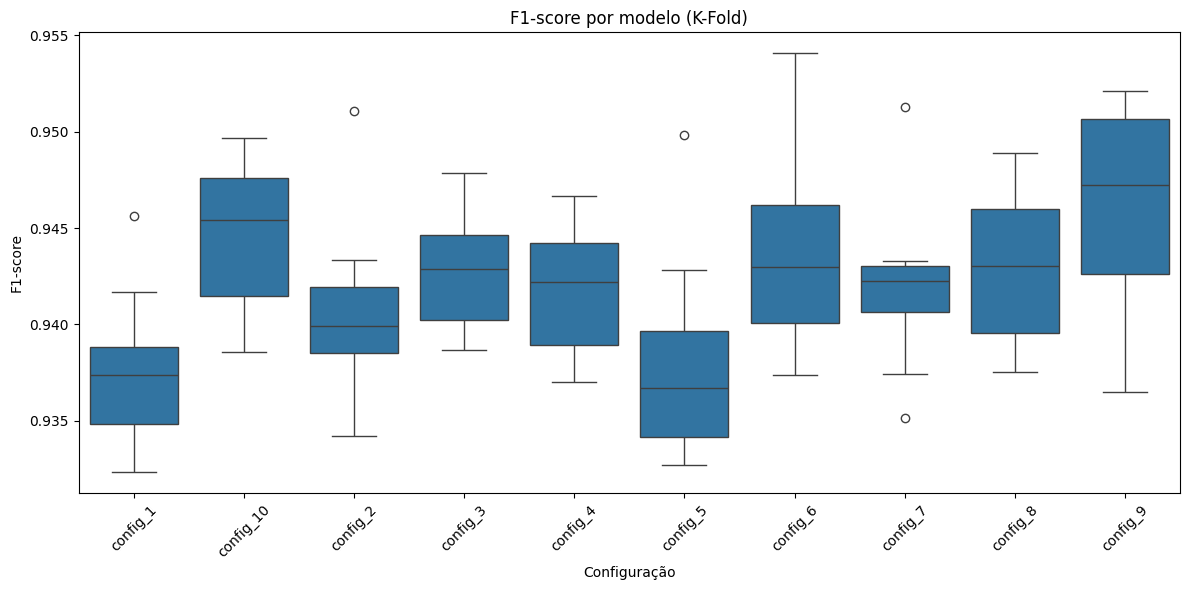

In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def plot_kfold_boxplot(df_matrix):
    df_long = df_matrix.reset_index().melt(
        id_vars="fold",
        var_name="config",
        value_name="f1"
    )

    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df_long, x="config", y="f1")

    plt.xticks(rotation=45)
    plt.title("F1-score por modelo (K-Fold)")
    plt.ylabel("F1-score")
    plt.xlabel("Configuração")

    plt.tight_layout()
    plt.show()

plot_kfold_boxplot(df_matrix)

#### Convergência

A convergência do treinamento foi avaliada a partir da evolução das métricas ao longo das épocas, bem como pelo comportamento do critério de early stopping. Observa-se que, para a maioria das configurações, o treinamento atinge rapidamente um patamar de desempenho estável, com melhorias marginais após um número relativamente reduzido de épocas.

O critério de early stopping foi baseado no F1-score de validação, alinhando o processo de interrupção do treinamento com a métrica final de avaliação. No entanto, essa escolha apresenta limitações, uma vez que o F1-score é uma métrica não contínua e mais suscetível a oscilações em comparação à função de perda, que é diretamente otimizada durante o treinamento. Em particular, pequenas variações nas probabilidades preditas podem não se refletir em mudanças no F1-score, o que pode impactar o momento de interrupção do treinamento.

Apesar dessas limitações, o uso de validação cruzada e de um parâmetro de paciência adequado contribuiu para mitigar esses efeitos, resultando em um processo de convergência estável no contexto deste trabalho.

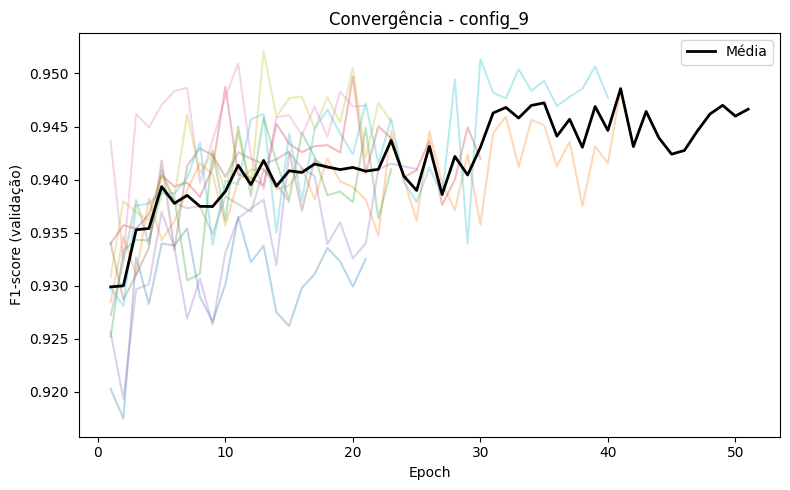

In [34]:
def plot_training_curve(kfold_histories, config_name):
    df = kfold_histories[config_name]

    plt.figure(figsize=(8, 5))

    for fold in df["fold"].unique():
        fold_df = df[df["fold"] == fold]
        plt.plot(fold_df["epoch"], fold_df["val_f1"], alpha=0.3)

    # média
    mean_curve = df.groupby("epoch")["val_f1"].mean()
    plt.plot(mean_curve.index, mean_curve.values, color="black", linewidth=2, label="Média")

    plt.title(f"Convergência - {config_name}")
    plt.xlabel("Epoch")
    plt.ylabel("F1-score (validação)")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_training_curve(kfold_histories, "config_9")

#### Regularização e controle de overfitting

A análise de regularização foi realizada a partir da comparação entre o desempenho nos conjuntos de treino e validação, bem como pela avaliação do impacto de estratégias como dropout e early stopping. De forma geral, não foram observados indícios fortes de sobreajuste, uma vez que as métricas de treino e validação permaneceram próximas ao longo do treinamento.

O uso de early stopping mostrou-se eficaz na prevenção de overfitting, interrompendo o treinamento quando não havia melhora significativa na métrica de validação. Adicionalmente, o uso de dropout em algumas configurações contribuiu para reduzir a variabilidade do modelo, embora seus efeitos não tenham sido uniformemente superiores em todos os cenários avaliados. Esses resultados sugerem que o problema apresenta uma complexidade moderada, não exigindo estratégias agressivas de regularização para alcançar bom desempenho.

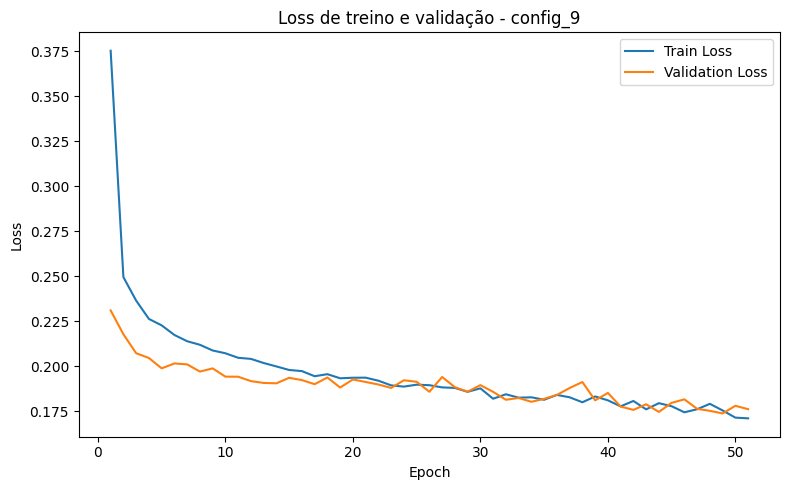

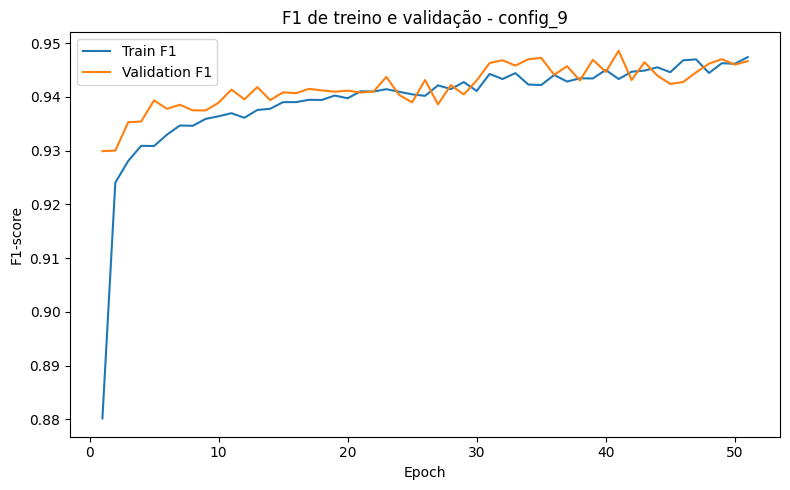

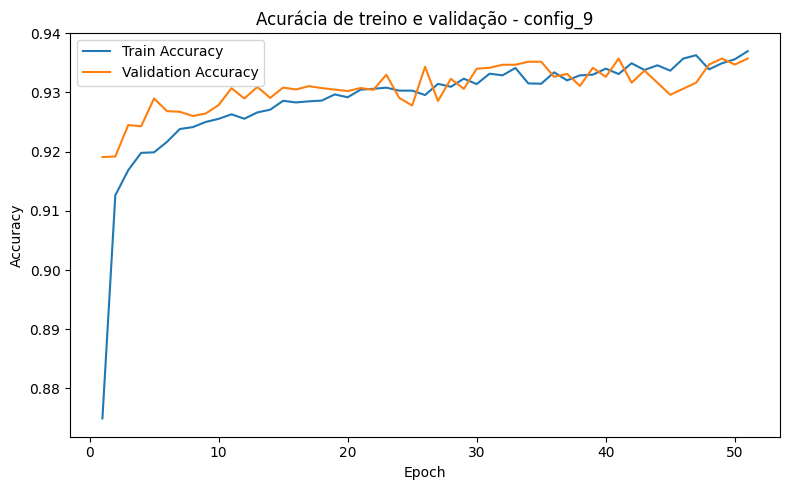

In [37]:
def plot_loss_curves(kfold_histories, config_name):
    df = kfold_histories[config_name].copy()

    mean_df = df.groupby("epoch").agg({
        "train_loss": "mean",
        "val_loss": "mean"
    })

    plt.figure(figsize=(8, 5))
    plt.plot(mean_df.index, mean_df["train_loss"], label="Train Loss")
    plt.plot(mean_df.index, mean_df["val_loss"], label="Validation Loss")

    plt.title(f"Loss de treino e validação - {config_name}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_f1_curves(kfold_histories, config_name):
    df = kfold_histories[config_name].copy()

    mean_df = df.groupby("epoch").agg({
        "train_f1": "mean",
        "val_f1": "mean"
    })

    plt.figure(figsize=(8, 5))
    plt.plot(mean_df.index, mean_df["train_f1"], label="Train F1")
    plt.plot(mean_df.index, mean_df["val_f1"], label="Validation F1")

    plt.title(f"F1 de treino e validação - {config_name}")
    plt.xlabel("Epoch")
    plt.ylabel("F1-score")
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_accuracy_curves(kfold_histories, config_name):
    df = kfold_histories[config_name].copy()

    mean_df = df.groupby("epoch").agg({
        "train_acc": "mean",
        "val_acc": "mean"
    })

    plt.figure(figsize=(8, 5))
    plt.plot(mean_df.index, mean_df["train_acc"], label="Train Accuracy")
    plt.plot(mean_df.index, mean_df["val_acc"], label="Validation Accuracy")

    plt.title(f"Acurácia de treino e validação - {config_name}")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_loss_curves(kfold_histories, "config_9")
plot_f1_curves(kfold_histories, "config_9")
plot_accuracy_curves(kfold_histories, "config_9")

As curvas de treino e validação, tanto para acurácia quanto para F1-score, apresentam comportamento bastante semelhante ao longo das épocas, sem a presença de um gap crescente entre elas. Em diversos momentos, o desempenho no conjunto de validação é inclusive ligeiramente superior ao de treino, o que pode ser atribuído à variabilidade dos dados e ao uso de técnicas como early stopping. Esse padrão indica ausência de sobreajuste significativo, sugerindo que o modelo generaliza adequadamente.

Já a análise da função de perda evidencia um comportamento consistente de convergência, com redução progressiva tanto da loss de treino quanto de validação. Não se observa divergência entre as curvas, o que reforça a ausência de sobreajuste e indica que o modelo está sendo otimizado de forma estável ao longo do treinamento.

#### Impacto do tamanho do batch


O tamanho do batch foi analisado em termos de seu impacto no desempenho preditivo e no custo computacional. Observa-se que diferentes valores de batch size (32 e 128) resultaram em desempenhos semelhantes em termos de F1-score, indicando que esse hiperparâmetro exerce influência limitada na qualidade final do modelo.

Por outro lado, diferenças relevantes foram observadas no tempo de treinamento, com batches maiores tendendo a reduzir o custo computacional por época. Esse comportamento sugere que o tamanho do batch atua principalmente como um parâmetro de eficiência computacional, sendo possível ajustar seu valor de acordo com restrições de tempo ou recursos, sem prejuízo significativo no desempenho do modelo.

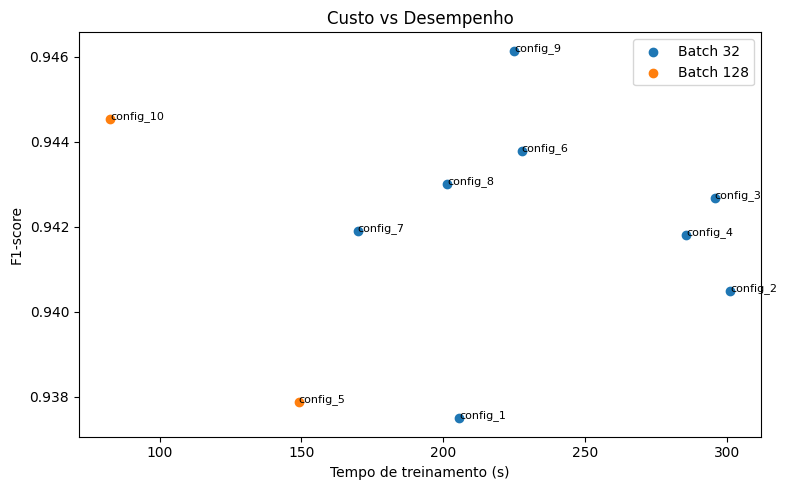

In [39]:
import matplotlib.pyplot as plt

def plot_time_vs_performance(df):
    plt.figure(figsize=(8, 5))

    # separa por batch
    df_32 = df[df["batch_size"] == 32]
    df_128 = df[df["batch_size"] == 128]

    # scatter com cores diferentes
    plt.scatter(
        df_32["training_time_sec"],
        df_32["validation_f1_macro"],
        label="Batch 32"
    )

    plt.scatter(
        df_128["training_time_sec"],
        df_128["validation_f1_macro"],
        label="Batch 128"
    )

    # labels dos pontos
    for _, row in df.iterrows():
        plt.text(
            row["training_time_sec"],
            row["validation_f1_macro"],
            row["config_name"],
            fontsize=8
        )

    plt.xlabel("Tempo de treinamento (s)")
    plt.ylabel("F1-score")
    plt.title("Custo vs Desempenho")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_time_vs_performance(kfold_export)

## Comparação Estatística

### Hipóteses

#### Hipótese 1: Modelos não lineares apresentam desempenho superior ao modelo linear

Os resultados indicam que a introdução de não-linearidade contribui positivamente para o desempenho do modelo. A configuração linear (`hidden_layers = []`) apresentou o segundo menor valor de F1-score entre as avaliadas (≈ 0.937), enquanto quase todas as arquiteturas com ao menos uma camada oculta obtiveram resultados superiores. Embora a diferença absoluta não seja elevada, o comportamento é consistente ao longo das configurações, sugerindo que o problema não é estritamente linear e se beneficia da capacidade adicional de representação introduzida pelas camadas ocultas.

#### Hipótese 2: O aumento da complexidade do modelo gera ganhos marginais de desempenho

Observa-se que arquiteturas mais complexas, como `[128, 64]` e `[64, 32]`, apresentam os maiores valores de F1-score (≈ 0.945–0.946), porém com ganhos reduzidos em relação a modelos mais simples, como `[16, 8]` ou `[16]`. A diferença entre o melhor e os modelos intermediários é inferior a 0.005, indicando que o aumento de capacidade não se traduz em melhorias proporcionais de desempenho. Esse comportamento sugere que o problema possui uma estrutura relativamente simples, sendo possível obter resultados competitivos com modelos de menor complexidade.

#### Hipótese 3: Modelos mais simples podem apresentar melhor relação custo-benefício

A análise conjunta de desempenho e tempo de treinamento sugere que modelos mais simples tendem a oferecer uma melhor relação custo-benefício. Embora arquiteturas mais profundas atinjam ligeiramente melhores valores de F1, o custo computacional associado é significativamente maior, tanto em termos de tempo total quanto de custo por época. Em contrapartida, configurações como `[16, 8]` e `[16]` apresentam desempenho próximo ao topo, com complexidade reduzida, o que as torna candidatas relevantes do ponto de vista prático. Esse resultado reforça a importância de considerar não apenas métricas preditivas, mas também o custo computacional na seleção de modelos.

#### Hipótese 4: O tamanho do batch impacta o custo computacional mais do que o desempenho

A comparação entre configurações com `batch_size = 32` e `128` sugere que o impacto do tamanho do batch no desempenho é limitado, uma vez que valores de F1-score semelhantes são observados entre diferentes configurações. No entanto, diferenças significativas são verificadas no tempo de treinamento, com algumas configurações utilizando batches maiores apresentando menor custo computacional por época. Esse comportamento indica que o batch size atua principalmente como um fator de eficiência computacional, com influência reduzida na qualidade final do modelo, embora essa hipótese também deva ser confirmada por meio de análise estatística.

Ainda assim, todas essa hipóteses devem ser confirmadas ou refutadas por meio de testes estatísticos, o que faremos na próxima seção.

### Verificação de Friedman e Nemenyi

Para realizar as comparações estatísticas vamos utilizar o teste de Friedman porque o problema envolve a comparação de múltiplos modelos de aprendizado supervisionado avaliados sobre os mesmos subconjuntos de dados, obtidos por meio de validação cruzada estratificada. Nesse contexto, cada *fold* pode ser interpretado como um bloco experimental, no qual todos os modelos são avaliados sob as mesmas condições, permitindo uma comparação pareada. Além disso, não é possível assumir normalidade na distribuição das métricas de desempenho (como o F1-score), especialmente considerando o número reduzido de observações (10 folds). Dessa forma, o teste de Friedman se mostra adequado por ser um método não paramétrico, robusto a essas limitações e amplamente utilizado na literatura para comparação de múltiplos algoritmos em cenários de validação cruzada.

Uma vez identificada a existência de diferenças estatisticamente significativas pelo teste de Friedman, torna-se necessário investigar quais pares de modelos diferem entre si. Para isso, será utilizado o teste post-hoc de Nemenyi, que permite realizar comparações múltiplas entre todos os pares de modelos, controlando o erro do tipo I associado a esse processo. O teste de Nemenyi é particularmente apropriado neste contexto, pois assume o mesmo desenho experimental do teste de Friedman, baseado em rankings por bloco, e não exige suposições adicionais sobre a distribuição dos dados. Assim, a combinação dos testes de Friedman e Nemenyi fornece um procedimento consistente e adequado para a análise estatística comparativa dos modelos avaliados.

In [22]:
from scipy.stats import friedmanchisquare
import scikit_posthocs as sp

def build_friedman_matrix(kfold_histories):
    """
    Constrói matriz (fold x modelo) com F1 macro.
    """
    data = []

    for config_name, df in kfold_histories.items():
        # pega o melhor resultado por fold (early stopping já escolheu)
        best_per_fold = (
            df.sort_values("val_f1", ascending=False)
              .groupby("fold")
              .first()
              .reset_index()
        )

        for _, row in best_per_fold.iterrows():
            data.append({
                "config": config_name,
                "fold": row["fold"],
                "f1": row["val_f1"]
            })

    df_long = pd.DataFrame(data)

    # pivot: linhas = folds, colunas = modelos
    df_pivot = df_long.pivot(index="fold", columns="config", values="f1")

    return df_pivot


def run_friedman_nemenyi(kfold_histories):
    df_matrix = build_friedman_matrix(kfold_histories)

    print("Matriz (fold x modelo):")
    display(df_matrix)

    # =========================
    # TESTE DE FRIEDMAN
    # =========================
    stat, p_value = friedmanchisquare(*[df_matrix[col] for col in df_matrix.columns])

    print("\n=== Friedman Test ===")
    print(f"Statistic: {stat:.4f}")
    print(f"P-value: {p_value:.6f}")

    if p_value < 0.05:
        print("Resultado: Diferença estatisticamente significativa encontrada.\n")

        # =========================
        # NEMENYI POST-HOC
        # =========================
        nemenyi = sp.posthoc_nemenyi_friedman(df_matrix)

        print("=== Nemenyi Post-hoc ===")
        display(nemenyi)

        return df_matrix, nemenyi

    else:
        print("Resultado: NÃO há evidência de diferença significativa.\n")
        return df_matrix, None

# Executa
df_matrix, nemenyi_results = run_friedman_nemenyi(kfold_histories)

Matriz (fold x modelo):


config,config_1,config_10,config_2,config_3,config_4,config_5,config_6,config_7,config_8,config_9
fold,,,,,,,,,,
1,0.932326,0.938578,0.935991,0.938850,0.937022,0.940310,0.937350,0.937422,0.938698,0.936505
2,0.935749,0.942411,0.940931,0.940527,0.938881,0.934105,0.939853,0.942001,0.937507,0.948574
3,0.936074,0.946772,0.942087,0.944463,0.941715,0.942798,0.943856,0.942494,0.942166,0.945851
4,0.938717,0.946747,0.943321,0.945803,0.942767,0.932691,0.946992,0.943219,0.942837,0.949714
5,0.938648,0.941125,0.934181,0.938665,0.938176,0.934217,0.938624,0.935126,0.937961,0.942525
6,0.938896,0.944117,0.938437,0.943827,0.944736,0.933798,0.943888,0.942470,0.943176,0.942945
7,0.945622,0.949674,0.951075,0.947860,0.946684,0.949832,0.950350,0.951271,0.948892,0.950963
8,0.932706,0.939716,0.938677,0.941884,0.939017,0.935814,0.940682,0.940414,0.944065,0.940960
9,0.934531,0.947867,0.941457,0.940158,0.942679,0.937541,0.942069,0.943285,0.946621,0.952101



=== Friedman Test ===
Statistic: 38.2255
P-value: 0.000016
Resultado: Diferença estatisticamente significativa encontrada.

=== Nemenyi Post-hoc ===


,config_1,config_10,config_2,config_3,config_4,config_5,config_6,config_7,config_8,config_9
config_1,1.000000,0.001455,0.975237,0.060077,0.796635,0.999687,0.023825,0.262239,0.224606,0.000556
config_10,0.001455,1.000000,0.091175,0.990232,0.303497,0.018568,0.999261,0.836319,0.871346,1.000000
config_2,0.975237,0.091175,1.000000,0.655209,0.999962,0.999962,0.445798,0.947071,0.926647,0.048208
config_3,0.060077,0.990232,0.655209,1.000000,0.926647,0.303497,1.000000,0.999882,0.999962,0.963100
config_4,0.796635,0.303497,0.999962,0.926647,1.000000,0.990232,0.796635,0.998421,0.996898,0.190715
config_5,0.999687,0.018568,0.999962,0.303497,0.990232,1.000000,0.160563,0.705351,0.655209,0.008432
config_6,0.023825,0.999261,0.445798,1.000000,0.796635,0.160563,1.000000,0.996898,0.998421,0.994324
config_7,0.262239,0.836319,0.947071,0.999882,0.998421,0.705351,0.996898,1.000000,1.000000,0.705351
config_8,0.224606,0.871346,0.926647,0.999962,0.996898,0.655209,0.998421,1.000000,1.000000,0.752761
config_9,0.000556,1.000000,0.048208,0.963100,0.190715,0.008432,0.994324,0.705351,0.752761,1.000000


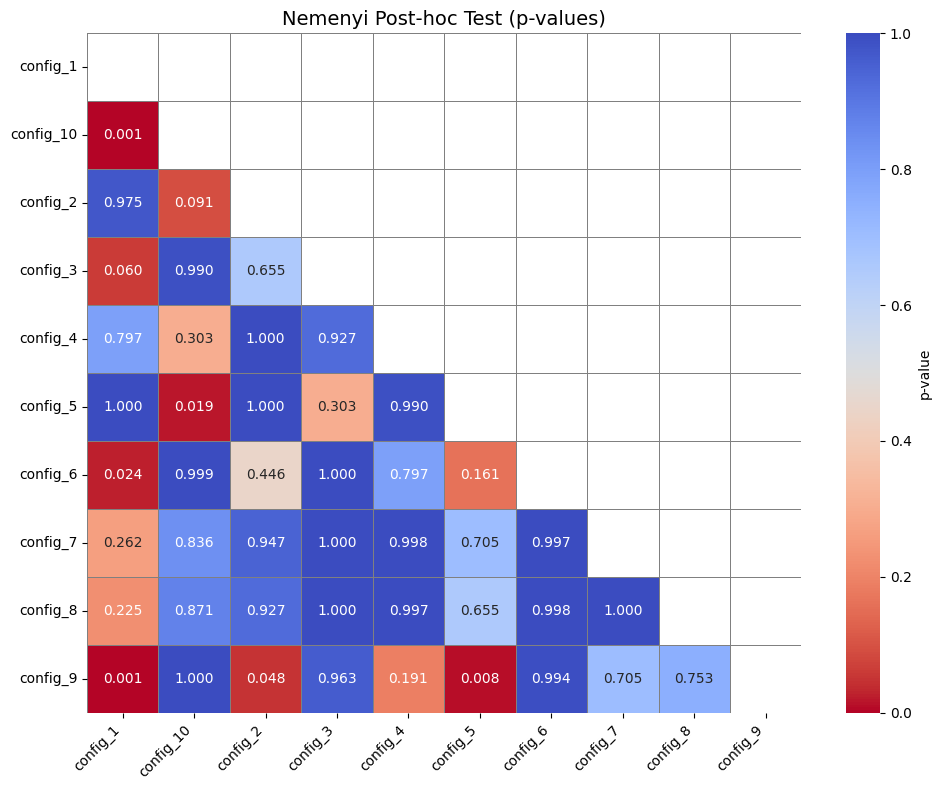

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_nemenyi_heatmap(nemenyi_df):
    plt.figure(figsize=(10, 8))

    # Máscara para esconder diagonal (opcional)
    mask = np.triu(np.ones_like(nemenyi_df, dtype=bool))

    sns.heatmap(
        nemenyi_df,
        annot=True,
        fmt=".3f",
        cmap="coolwarm_r",
        vmin=0,
        vmax=1,
        linewidths=0.5,
        linecolor='gray',
        mask=mask,
        cbar_kws={"label": "p-value"}
    )

    plt.title("Nemenyi Post-hoc Test (p-values)", fontsize=14)
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)

    plt.tight_layout()
    plt.show()


# Executa
plot_nemenyi_heatmap(nemenyi_results)

### Avaliação das hipóteses

Com base nos resultados obtidos a partir dos testes de Friedman e Nemenyi, bem como na análise das distribuições de desempenho entre os folds, é possível avaliar as hipóteses propostas:

**Hipótese 1: Modelos não lineares apresentam desempenho superior ao modelo linear — Confirmada.**  
O teste de Nemenyi evidenciou que o modelo linear apresenta desempenho estatisticamente inferior em relação a diversas configurações não lineares. Essa diferença, embora pequena em termos absolutos, mostrou-se consistente ao longo dos folds, indicando que a introdução de não-linearidade contribui efetivamente para a melhoria do desempenho.

**Hipótese 2: O aumento da complexidade do modelo gera ganhos marginais de desempenho — Parcialmente confirmada.**  
Apesar de modelos mais complexos apresentarem maiores valores médios de F1-score, o teste de Nemenyi não identificou diferenças estatisticamente significativas entre a maioria das arquiteturas não lineares. Isso indica que, embora haja uma tendência de melhoria com o aumento da complexidade, esses ganhos não são suficientemente consistentes para serem considerados significativos, caracterizando-os como marginais.

**Hipótese 3: Modelos mais simples podem apresentar melhor relação custo-benefício — Confirmada.**  
A análise conjunta dos resultados mostra que modelos de menor complexidade apresentam desempenho estatisticamente equivalente aos modelos mais complexos, porém com menor custo computacional. Dessa forma, configurações mais simples emergem como alternativas mais eficientes do ponto de vista prático, oferecendo um melhor equilíbrio entre desempenho e custo.

**Hipótese 4: O tamanho do batch impacta o custo computacional mais do que o desempenho — Inconclusiva.**  
Embora a análise empírica indique diferenças relevantes no tempo de treinamento associadas ao tamanho do batch, não foi possível isolar estatisticamente o impacto desse hiperparâmetro no desempenho preditivo. As comparações realizadas envolvem múltiplos fatores simultaneamente, o que limita a capacidade de atribuir causalidade direta ao tamanho do batch, tornando essa hipótese inconclusiva no contexto deste experimento.

### Salvando os histories do grid search e do treinamento

In [24]:
import pickle

# full grid search histories
with open("histories.pkl", "wb") as f:
    pickle.dump(histories, f)

# simple grid search histories
with open("simple_histories.pkl", "wb") as f:
    pickle.dump(simple_histories, f)

# k-fold histories
with open("kfold_histories.pkl", "wb") as f:
    pickle.dump(kfold_histories, f)


Os resultados obtidos a partir do teste de Friedman indicaram a existência de diferenças estatisticamente significativas entre os modelos avaliados, evidenciando que o desempenho observado não pode ser atribuído apenas à variabilidade dos dados entre os folds. A aplicação do teste post-hoc de Nemenyi permitiu aprofundar essa análise, revelando que tais diferenças estão concentradas principalmente entre o modelo linear e as arquiteturas não lineares, sendo o primeiro consistentemente inferior. Por outro lado, não foram identificadas diferenças estatisticamente significativas entre a maioria das arquiteturas não lineares, mesmo entre aquelas com níveis distintos de complexidade. Esse resultado sugere a formação de grupos de modelos estatisticamente equivalentes, nos quais o aumento da capacidade não se traduz em ganhos consistentes de desempenho. Em conjunto, esses achados reforçam a importância de uma análise estatística formal, uma vez que diferenças aparentemente relevantes em termos absolutos podem não ser sustentadas quando considerada a variabilidade experimental.

### Salvando os resultados da comparação estatística

In [32]:
kfold_results_with_std.to_csv("kfold_results_with_std.csv", index=True)

df_matrix.to_csv("results_friedman_matrix.csv", index=True)

if nemenyi_results is not None:
    nemenyi_results.to_csv("results_nemenyi_matrix.csv", index=True)

## Testando o modelo escolhido

## Conclusões

Os resultados obtidos neste estudo permitem extrair conclusões relevantes acerca do impacto da complexidade do modelo e de seus hiperparâmetros no desempenho da tarefa de classificação. A análise estatística, conduzida por meio do teste de Friedman seguido do teste post-hoc de Nemenyi, indicou a existência de diferenças estatisticamente significativas entre os modelos avaliados. Em particular, verificou-se que o modelo linear apresentou desempenho inferior de forma consistente, confirmando que a introdução de não-linearidade contribui positivamente para a capacidade preditiva do modelo.

Por outro lado, não foram observadas diferenças estatisticamente significativas entre arquiteturas não lineares de diferentes níveis de complexidade, incluindo configurações intermediárias e mais profundas. Esse resultado sugere que o aumento da capacidade do modelo não implica, necessariamente, em ganhos relevantes de desempenho para o problema em questão, caracterizando tais ganhos como marginais. Dessa forma, modelos de menor complexidade mostram-se suficientes para capturar a estrutura dos dados, sem prejuízo significativo na qualidade das predições.

Adicionalmente, ao considerar o custo computacional associado ao treinamento, observa-se que modelos mais simples apresentam vantagens práticas importantes, uma vez que oferecem desempenho estatisticamente equivalente a modelos mais complexos, com menor tempo de execução. Esse aspecto reforça a importância de avaliar conjuntamente métricas de desempenho e custo computacional na seleção de modelos.

Por fim, embora diferenças no tamanho do *batch* tenham demonstrado impacto no custo de treinamento, não foi possível estabelecer evidência estatística suficiente para afirmar que esse fator influencia o desempenho preditivo de forma significativa. Investigações adicionais, com experimentos controlados, seriam necessárias para isolar e avaliar adequadamente esse efeito. Em conjunto, os resultados indicam que a escolha de modelos para este problema deve priorizar arquiteturas não lineares de complexidade moderada, equilibrando desempenho e eficiência computacional.